# Fig: search space setup and updates

In [1]:
from pathlib import Path
""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from infotaxis import one_target
from infotaxis import hex_ops, utils

In [2]:
path_fig = Path("../figs")

In [3]:
# pm/pfa
pm = 0.005
pfa = 0.005

In [4]:
# Set params, target location, beam axis
canvas_range = 5  # radius of field
canvas_cube = hex_ops.cube_within_radius((0,0,0), canvas_range)  # canvas in cube coorindate
canvas_axial = hex_ops.cube_to_axial(canvas_cube)        # canvas in axial coorindate
k_canvas = hex_ops.axial_to_k(canvas_axial, canvas_axial)  # flattened vector for canvas axial coodinate

d = np.array([1/canvas_cube.shape[0]] * canvas_cube.shape[0])
d[0]

np.float64(0.01098901098901099)

In [5]:
# Set up a target and first beam locations
target_cube = (-1, +3, -2)
target_plotxy = hex_ops.get_cube_plot_xy(target_cube)
k_target = hex_ops.axial_to_k(hex_ops.cube_to_axial(target_cube), canvas_axial)

beam_first_cube = (-2, 0, +2)
beam_first_plotxy = hex_ops.get_cube_plot_xy(beam_first_cube)
k_beam_first = hex_ops.axial_to_k(hex_ops.cube_to_axial(beam_first_cube), canvas_axial)
beam_cover_first_cube = utils.beam_shape_hex(beam_first_cube, canvas_axial, 1)  # beam coverage

In [6]:
prob_example_cube = np.expand_dims(np.array([+4, -2, -2]), axis=0)

## Initial map

In [7]:
search_dict = None
param_echo = {
    str(1): {
        "pm_const": pm,
        "pfa_const": pfa,
    },
}

In [8]:
oth = one_target.OneTargetHex(
    search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
    canvas_radius=5,
    beam_radius=[1],
    target_cube=(1, -2, 1),
    aim_start_cube=(-2, 0, +2),
    param_animal= param_echo,
    param_echo= param_echo,
    search_dict=search_dict
)

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


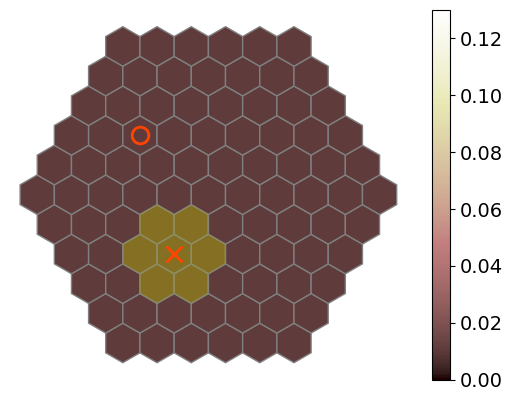

In [9]:
# Target probability map

fig,ax = plt.subplots(1)

# plot canvas
im, cbar = hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.d,
                      cmap="pink", vmin_vmax=(0,0.13), gridalpha=1)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.tick_params(labelsize=14)

# plot beam
hex_ops.plot_hexgrids(ax, cube_array=beam_cover_first_cube,
                      cube_color="y", gridalpha=0.4)

# plot target loc
ht = plt.plot(target_plotxy[0], target_plotxy[1],
              "o", markeredgewidth=2, markersize=12,
              markerfacecolor="None", markeredgecolor="orangered")

# plot beam axis
hb = plt.plot(beam_first_plotxy[0], beam_first_plotxy[1],
              "x", color="orangered",
              markeredgewidth=2, markersize=12)

# # yellow cell for prob example
# hg = hex_ops.plot_hexgrids(ax, cube_array=prob_example_cube,
#                            cube_color="y", gridalpha=0.9)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_prob_start.png", transparent=False, dpi=150)

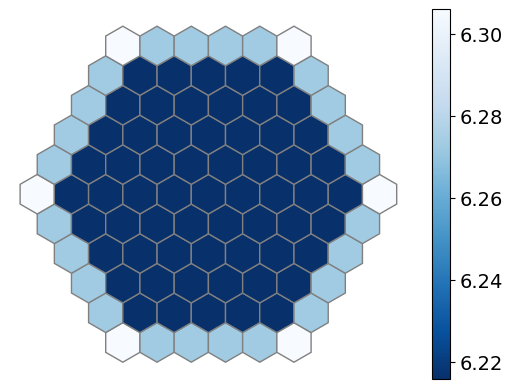

In [10]:
# Estimated entropy

fig,ax = plt.subplots(1)

# plot canvas
im, cbar = hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.h_est[1],
                      cmap="Blues_r", gridalpha=1)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.tick_params(labelsize=14)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_est_entropy_start.png", transparent=False, dpi=150)

## Update: X=0 (no echo)

In [11]:
search_dict = None
param_echo = {
    str(1): {
        "pm_const": pm,
        "pfa_const": pfa,
    },
}

In [12]:
oth = one_target.OneTargetHex(
    search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
    canvas_radius=5,
    beam_radius=[1],
    target_cube=(1, -2, 1),
    aim_start_cube=(-2, 0, +2),
    param_animal= param_echo,
    param_echo= param_echo,
    search_dict=search_dict
)

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


In [13]:
oth.echo_value = False
oth.update_X0()

In [14]:
# Update h after updating the map
oth.get_h_actual()
oth.get_est_ph()

In [15]:
np.max(oth.d)

np.float64(0.011899778747832327)

In [16]:
beam_first_plotxy = hex_ops.get_cube_plot_xy((-2, 0, +2))

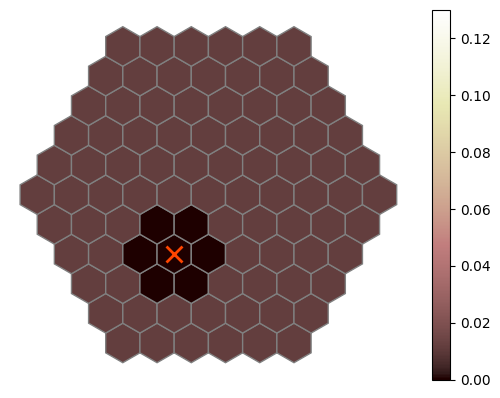

In [17]:
# Target probability map after update

fig,ax = plt.subplots(1)

# Plot updated map
hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.d,   # plot canvas
                      cmap="pink", vmin_vmax=(0,0.13), gridalpha=1)

# plot beam axis
hb = plt.plot(beam_first_plotxy[0], beam_first_plotxy[1],   # plot beam axis
              "x", color="orangered",
              markeredgewidth=2, markersize=12)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_prob_update_X0.png", transparent=False, dpi=150)

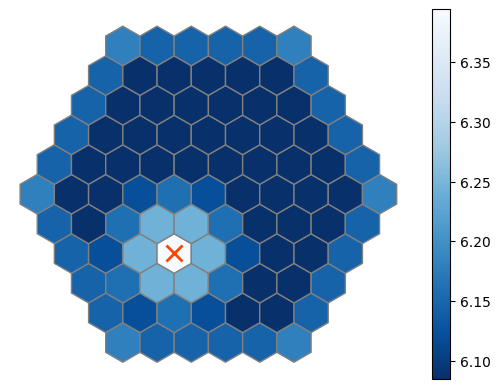

In [18]:
# Estimated entropy after update

fig,ax = plt.subplots(1)

# Plot updated map
hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.h_est[1],   # plot canvas
                      cmap="Blues_r", gridalpha=1)

# plot beam axis
hb = plt.plot(beam_first_plotxy[0], beam_first_plotxy[1],   # plot beam axis
              "x", color="orangered",
              markeredgewidth=2, markersize=12)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_est_entropy_update_X0.png", transparent=False, dpi=150)

## Update: X=1 (echo)

In [19]:
search_dict = None
param_echo = {
    str(1): {
        "pm_const": pm,
        "pfa_const": pfa,
    },
}

In [20]:
oth = one_target.OneTargetHex(
    search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
    canvas_radius=5,
    beam_radius=[1],
    target_cube=(1, -2, 1),
    aim_start_cube=(-2, 0, +2),
    param_animal= param_echo,
    param_echo= param_echo,
    search_dict=search_dict
)

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


In [21]:
oth.echo_value = False
oth.update_X1()

In [22]:
# Update h after updating the map
oth.get_h_actual()
oth.get_est_ph()

In [23]:
beam_first_plotxy = hex_ops.get_cube_plot_xy((-2, 0, +2))

In [24]:
np.max(oth.d)

np.float64(0.10090423857085341)

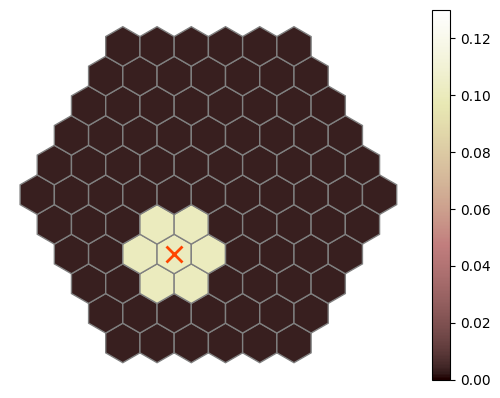

In [25]:
# Estimated target probability after update

fig,ax = plt.subplots(1)

# Plot updated map
hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.d,   # plot canvas
                      cmap="pink", vmin_vmax=(0,0.13), gridalpha=1)

# plot beam axis
hb = plt.plot(beam_first_plotxy[0], beam_first_plotxy[1],   # plot beam axis
              "x", color="orangered",
              markeredgewidth=2, markersize=12)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_prob_update_X1.png", transparent=False, dpi=150)

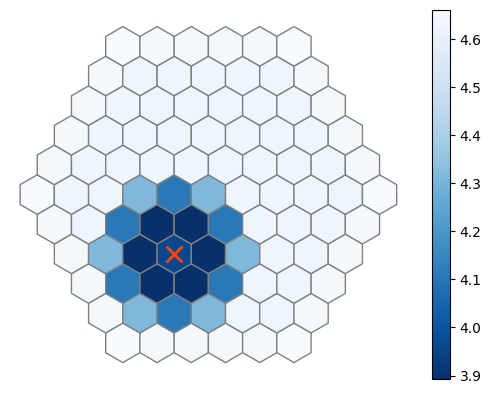

In [26]:
# Estimated entropy after update

fig,ax = plt.subplots(1)

# Plot updated map
hex_ops.plot_hexgrids(ax, cube_array=canvas_cube, cube_color=oth.h_est[1],   # plot canvas
                      cmap="Blues_r", gridalpha=1)

# plot beam axis
hb = plt.plot(beam_first_plotxy[0], beam_first_plotxy[1],   # plot beam axis
              "x", color="orangered",
              markeredgewidth=2, markersize=12)

ax.axis("equal")
# fig.patch.set_visible(False)
ax.patch.set_visible(False)
ax.axis("off")

plt.show()

fig.savefig(path_fig / "fig_setup_est_entropy_update_X1.png", transparent=False, dpi=150)